# Estimativa de Peso de Bovinos por Medidas Morfométricas

**Objetivo:** Comparar modelos de machine learning para prever o peso vivo de vacas Hereford a partir de medidas corporais simples, sem necessidade de balança industrial.

**Dataset:** Hereford_cows - Ruchay et al. (2022) | 1.523 vacas | 11 medidas corporais + idade

**Por que isso é relevante para a região da Campanha Gaucha?**  
A Campanha Gaúcha tem uma das maiores concentrações de pecuária de corte do país, com Hereford e Braford dominando os campos nativos do Pampa. Monitorar ganho de peso é parte do dia a dia do produtor, mas balança de precisão ainda é realidade de poucos. Com medidas tiradas no manejo rotineiro e um modelo treinado, qualquer propriedade consegue estimar o peso dos animais sem custo extra.

## 0. Instalação de Dependências

In [22]:
!pip install shap xgboost --quiet
print('Dependências prontas')

Dependências prontas


## 1. Imports e Configuração

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from scipy import stats
from xgboost import XGBRegressor
import shap
import pickle, os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
SEED = 42
np.random.seed(SEED)
print('Imports OK')

Imports OK


## 2. Carregamento e Padronização

In [24]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/jota6k/projeto_peso_bovinos/main/data/Hereford_cows.csv',
    encoding='latin-1',
    sep=';'
)

df = df.drop(columns=['n.', 'identificator'])

df = df.rename(columns={
    'Age years':              'idade_anos',
    'Body weight':            'peso_kg',
    'withers height':         'altura_cernelha',
    'hip height':             'altura_garupa',
    'chest depth':            'profundidade_peito',
    'chest width':            'largura_peito',
    'heart girth':            'perimetro_toracico',
    'ilium width':            'largura_iliaca',
    'sciatic tubercle width': 'largura_isquiatica',
    'oblique body length':    'comp_obliquo_corpo',
    'oblique rear length':    'comp_obliquo_traseiro',
    'metacarpus girth':       'perimetro_metacarpo',
    'backside half-girth':    'meia_circ_traseira',
})

FEATURES = [
    'altura_cernelha', 'altura_garupa', 'profundidade_peito',
    'largura_peito', 'perimetro_toracico', 'largura_iliaca',
    'largura_isquiatica', 'comp_obliquo_corpo', 'comp_obliquo_traseiro',
    'perimetro_metacarpo', 'meia_circ_traseira', 'idade_anos'
]
TARGET = 'peso_kg'

NOMES_PT = {
    'altura_cernelha':       'Altura Cernelha (cm)',
    'altura_garupa':         'Altura Garupa (cm)',
    'profundidade_peito':    'Prof. Peito (cm)',
    'largura_peito':         'Larg. Peito (cm)',
    'perimetro_toracico':    'Perím. Torácico (cm)',
    'largura_iliaca':        'Larg. Ilíaca (cm)',
    'largura_isquiatica':    'Larg. Isquiática (cm)',
    'comp_obliquo_corpo':    'Comp. Oblíquo Corpo (cm)',
    'comp_obliquo_traseiro': 'Comp. Oblíquo Traseiro (cm)',
    'perimetro_metacarpo':   'Perím. Metacarpo (cm)',
    'meia_circ_traseira':    'Meia Circ. Traseira (cm)',
    'idade_anos':            'Idade (anos)',
    'area_corporal':   'Área Corporal (cm²)',
    'ratio_altura':    'Ratio Cernelha/Garupa',
    'volume_estimado': 'Volume Estimado (cm³)',
}

# Remove único valor nulo (perimetro_metacarpo)
df = df.dropna()

print(f'Dataset: {df.shape[0]} animais, {df.shape[1]} variáveis')
print(f'Features: {len(FEATURES)} | Target: {TARGET}')
print()
print(df[FEATURES + [TARGET]].describe().round(2))

Dataset: 1522 animais, 13 variáveis
Features: 12 | Target: peso_kg

       altura_cernelha  altura_garupa  profundidade_peito  largura_peito  \
count          1522.00        1522.00             1522.00        1522.00   
mean            126.73         130.00               66.03          46.74   
std               3.80           4.05                6.64           6.53   
min             112.00         116.00               12.00          10.00   
25%             125.00         128.00               62.00          42.00   
50%             127.00         130.00               67.00          45.00   
75%             129.00         132.00               70.00          50.00   
max             141.00         147.00               88.00          72.00   

       perimetro_toracico  largura_iliaca  largura_isquiatica  \
count             1522.00         1522.00             1522.00   
mean               189.18           51.63               26.29   
std                 12.62            5.87           

## 3. Análise Exploratória (EDA)

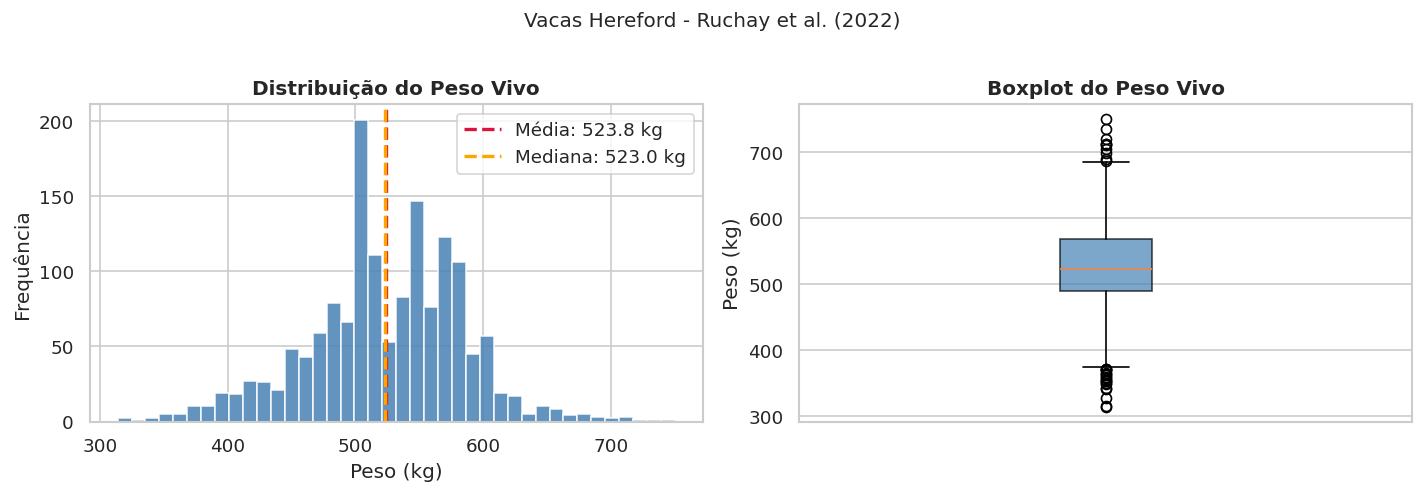

Assimetria: -0.204 | Curtose: 0.516


In [25]:
# Distribuição do peso
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[TARGET], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df[TARGET].mean(), color='crimson', linestyle='--', linewidth=2,
                label=f'Média: {df[TARGET].mean():.1f} kg')
axes[0].axvline(df[TARGET].median(), color='orange', linestyle='--', linewidth=2,
                label=f'Mediana: {df[TARGET].median():.1f} kg')
axes[0].set_title('Distribuição do Peso Vivo', fontweight='bold')
axes[0].set_xlabel('Peso (kg)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

axes[1].boxplot(df[TARGET], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot do Peso Vivo', fontweight='bold')
axes[1].set_ylabel('Peso (kg)')
axes[1].set_xticks([])

plt.suptitle('Vacas Hereford - Ruchay et al. (2022)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()
print(f'Assimetria: {df[TARGET].skew():.3f} | Curtose: {df[TARGET].kurtosis():.3f}')

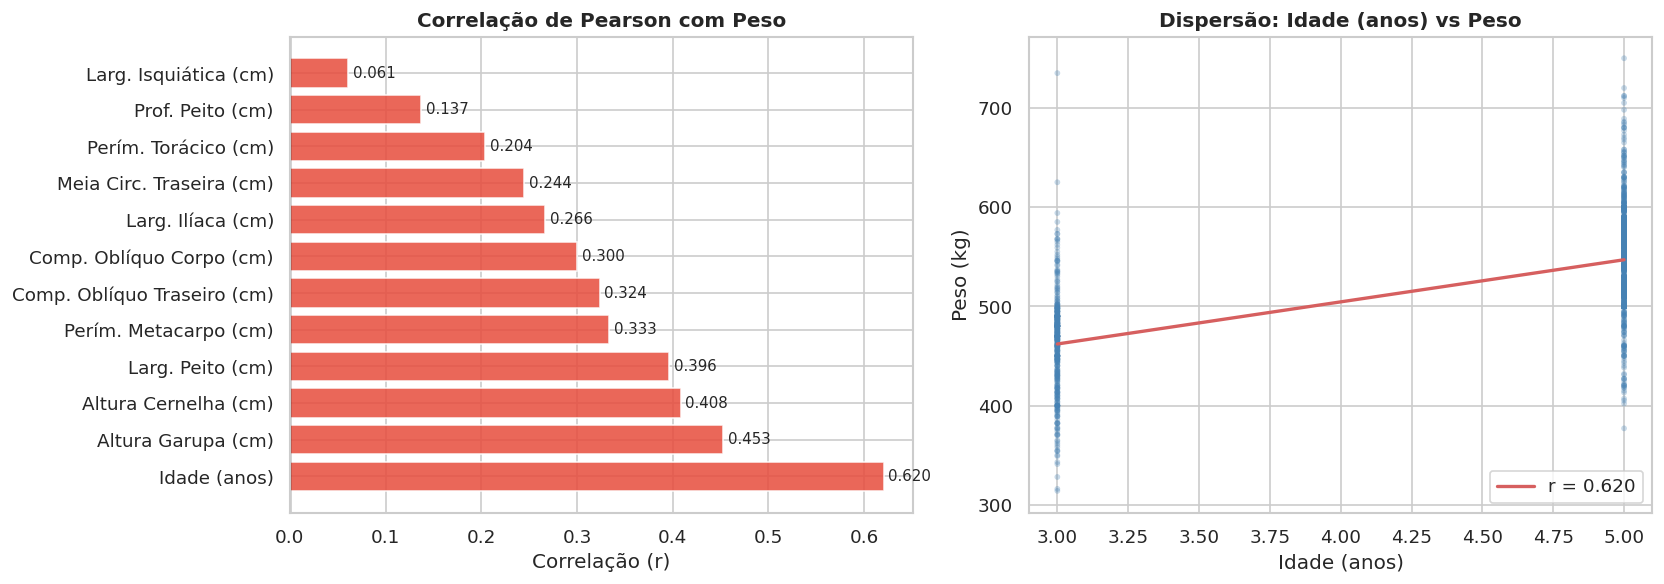

In [26]:
# Correlação das features com o peso
corr_com_peso = df[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cores = ['#e74c3c' if v > 0 else '#3498db' for v in corr_com_peso]
axes[0].barh([NOMES_PT.get(f, f) for f in corr_com_peso.index],
             corr_com_peso.values, color=cores, alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Correlação de Pearson com Peso', fontweight='bold')
axes[0].set_xlabel('Correlação (r)')
for i, v in enumerate(corr_com_peso.values):
    axes[0].text(v + 0.005 if v > 0 else v - 0.005, i,
                 f'{v:.3f}', va='center', ha='left' if v > 0 else 'right', fontsize=9)

top_feat = corr_com_peso.index[0]
axes[1].scatter(df[top_feat], df[TARGET], alpha=0.3, s=12, color='steelblue', edgecolors='none')
z = np.polyfit(df[top_feat], df[TARGET], 1)
x_line = np.linspace(df[top_feat].min(), df[top_feat].max(), 200)
axes[1].plot(x_line, np.poly1d(z)(x_line), 'r-', linewidth=2,
             label=f'r = {corr_com_peso[top_feat]:.3f}')
axes[1].set_xlabel(NOMES_PT.get(top_feat, top_feat))
axes[1].set_ylabel('Peso (kg)')
axes[1].set_title(f'Dispersão: {NOMES_PT.get(top_feat, top_feat)} vs Peso', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()

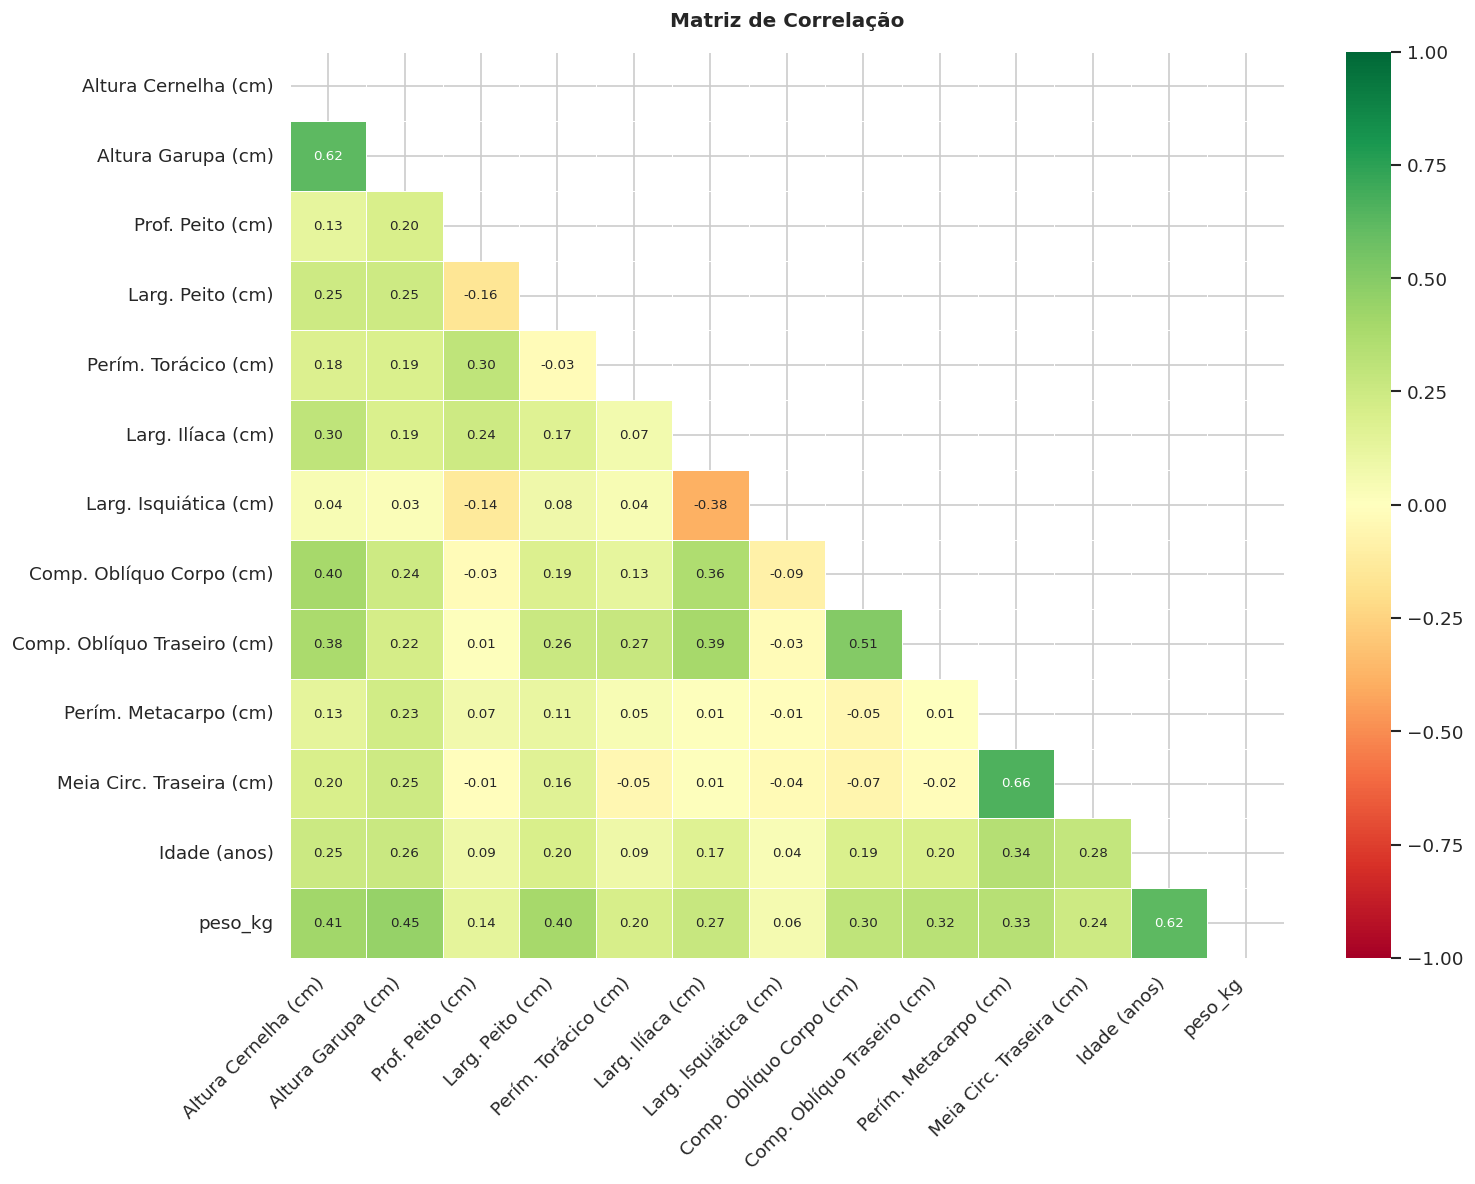

In [27]:
# Heatmap de correlação
fig, ax = plt.subplots(figsize=(13, 10))
cols = FEATURES + [TARGET]
labels = [NOMES_PT.get(c, c) for c in cols]
corr_matrix = df[cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Matriz de Correlação', fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Pré-processamento

In [28]:
# Feature engineering
df['area_corporal']   = df['comp_obliquo_corpo'] * df['perimetro_toracico']
df['ratio_altura']    = df['altura_cernelha'] / df['altura_garupa']
df['volume_estimado'] = df['perimetro_toracico']**2 * df['comp_obliquo_corpo']
FEATURES += ['area_corporal', 'ratio_altura', 'volume_estimado']

X = df[FEATURES].copy()
y = df[TARGET].copy()

# Remove outliers extremos (1% e 99%)
mask_outlier = (y >= y.quantile(0.01)) & (y <= y.quantile(0.99))
X = X[mask_outlier].reset_index(drop=True)
y = y[mask_outlier].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

print(f'Treino: {len(X_train)} | Teste: {len(X_test)}')
print(f'Peso médio treino: {y_train.mean():.1f} kg | teste: {y_test.mean():.1f} kg')

Treino: 1192 | Teste: 299
Peso médio treino: 524.7 kg | teste: 519.3 kg


In [29]:
# Escalonamento global (Disponível para tuning, SHAP e simulador)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('Dados escalonados prontos')

Dados escalonados prontos


## 5. Modelagem

In [30]:
MODELOS = {
    'Regressão Linear':  Pipeline([('sc', StandardScaler()), ('m', LinearRegression())]),
    'Ridge':             Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=1.0))]),
    'KNN (k=7)':         Pipeline([('sc', StandardScaler()), ('m', KNeighborsRegressor(n_neighbors=7))]),
    'SVR (RBF)':         Pipeline([('sc', StandardScaler()), ('m', SVR(kernel='rbf', C=100, epsilon=5))]),
    'Random Forest':     Pipeline([('sc', StandardScaler()), ('m', RandomForestRegressor(
                             n_estimators=200, min_samples_leaf=2, random_state=SEED, n_jobs=-1))]),
    'Gradient Boosting': Pipeline([('sc', StandardScaler()), ('m', GradientBoostingRegressor(
                             n_estimators=300, learning_rate=0.05, max_depth=4, random_state=SEED))]),
}

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
resultados = []

print(f'{"Modelo":<22} {"MAE":>8} {"RMSE":>8} {"R²":>7} {"CV R²":>14}')
print('-' * 65)

for nome, pipe in MODELOS.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)
    cv   = cross_val_score(pipe, X, y, cv=kf, scoring='r2', n_jobs=-1)
    resultados.append({'Modelo': nome, 'MAE': mae, 'RMSE': rmse, 'R2': r2,
                       'CV_mean': cv.mean(), 'CV_std': cv.std(), 'pred': pred})
    print(f'{nome:<22} {mae:>8.2f} {rmse:>8.2f} {r2:>7.3f}  {cv.mean():.3f} ± {cv.std():.3f}')

melhor = max(resultados, key=lambda x: x['R2'])['Modelo']
print(f'\nMelhor modelo (R²): {melhor}')

Modelo                      MAE     RMSE      R²          CV R²
-----------------------------------------------------------------
Regressão Linear          29.26    36.65   0.572  0.555 ± 0.044
Ridge                     29.23    36.58   0.573  0.555 ± 0.043
KNN (k=7)                 25.74    33.16   0.649  0.641 ± 0.014
SVR (RBF)                 24.63    31.93   0.675  0.638 ± 0.034
Random Forest             22.69    29.41   0.724  0.692 ± 0.036
Gradient Boosting         23.73    30.56   0.702  0.673 ± 0.039

Melhor modelo (R²): Random Forest


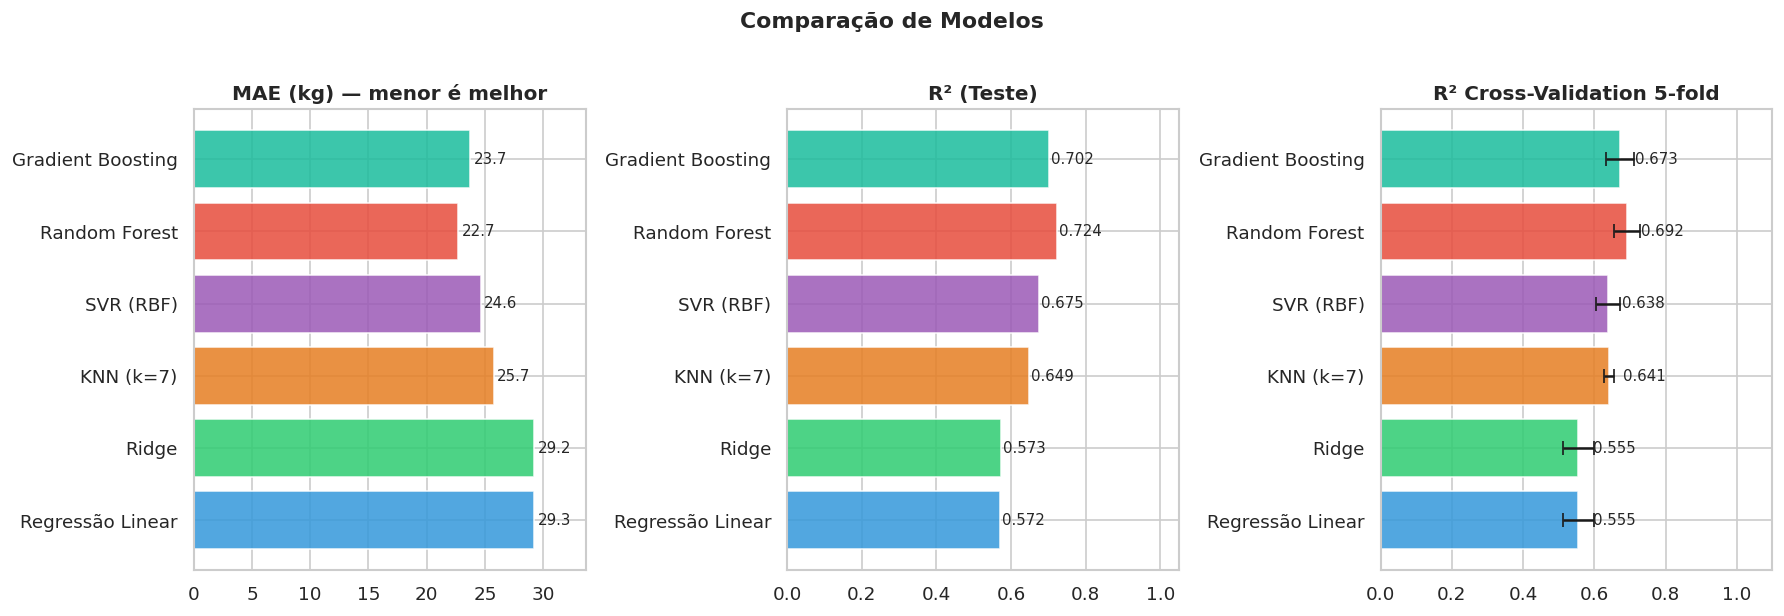

In [42]:
# Comparativo visual
CORES = ['#3498db','#2ecc71','#e67e22','#9b59b6','#e74c3c','#1abc9c']
nomes = [r['Modelo'] for r in resultados]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MAE — eixo normal (menor = melhor)
bars = axes[0].barh(nomes, [r['MAE'] for r in resultados], color=CORES, alpha=0.85, edgecolor='white')
axes[0].set_title('MAE (kg)', fontweight='bold')
axes[0].set_xlim(0, max([r['MAE'] for r in resultados]) * 1.15)
for bar, v in zip(bars, [r['MAE'] for r in resultados]):
    axes[0].text(v + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{v:.1f}', va='center', fontsize=9)

# R² Teste
bars = axes[1].barh(nomes, [r['R2'] for r in resultados], color=CORES, alpha=0.85, edgecolor='white')
axes[1].set_title('R² (Teste)', fontweight='bold')
axes[1].set_xlim(0, 1.05)
for bar, v in zip(bars, [r['R2'] for r in resultados]):
    axes[1].text(v + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{v:.3f}', va='center', fontsize=9)

# R² Cross-Validation com valores nas barras
bars = axes[2].barh(nomes, [r['CV_mean'] for r in resultados], color=CORES, alpha=0.85,
                    xerr=[r['CV_std'] for r in resultados], capsize=4, edgecolor='white')
axes[2].set_title('R² Cross-Validation 5-fold', fontweight='bold')
axes[2].set_xlim(0, 1.1)
for bar, v in zip(bars, [r['CV_mean'] for r in resultados]):
    axes[2].text(v + 0.04, bar.get_y() + bar.get_height()/2,
                 f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Comparação de Modelos', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

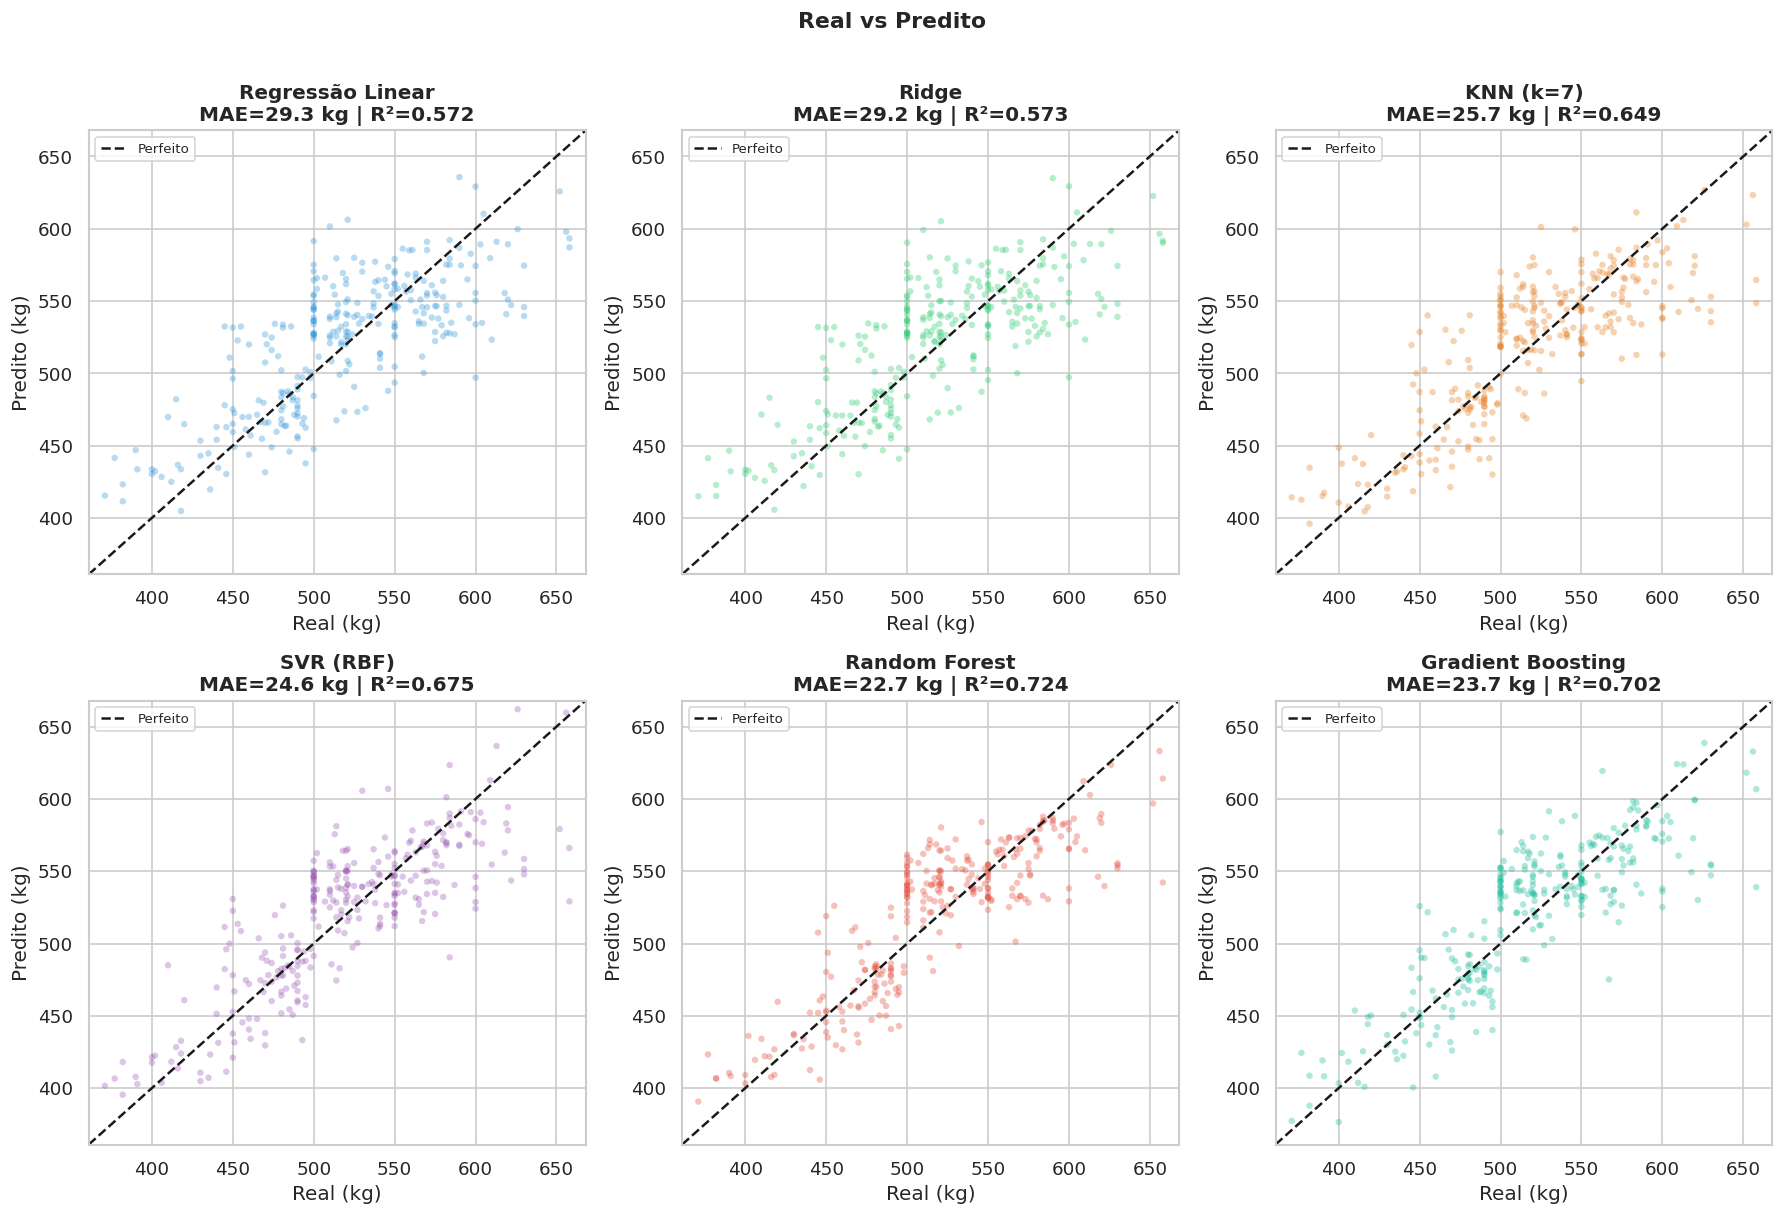

In [32]:
# Real vs Predito
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
lim = (y_test.min() - 10, y_test.max() + 10)

for i, res in enumerate(resultados):
    axes[i].scatter(y_test, res['pred'], alpha=0.35, s=15, color=CORES[i], edgecolors='none')
    axes[i].plot(lim, lim, 'k--', linewidth=1.5, label='Perfeito')
    axes[i].set_xlim(lim); axes[i].set_ylim(lim)
    axes[i].set_xlabel('Real (kg)'); axes[i].set_ylabel('Predito (kg)')
    axes[i].set_title(f'{res["Modelo"]}\nMAE={res["MAE"]:.1f} kg | R²={res["R2"]:.3f}', fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Real vs Predito', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Análise do Melhor Modelo - Random Forest com RandomizedSearchCV

In [33]:
param_grid = {
    'n_estimators':     [200, 400, 600],
    'max_depth':        [10, 20, 30, None],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2', 0.5],
}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    param_grid, n_iter=30, cv=5, scoring='r2',
    random_state=SEED, n_jobs=-1, verbose=0
)
search.fit(X_train_sc, y_train)

rf = search.best_estimator_
pred_rf = rf.predict(X_test_sc)

mae_rf  = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf   = r2_score(y_test, pred_rf)
mape_rf = np.mean(np.abs((y_test - pred_rf) / y_test)) * 100

print(f'Melhores parâmetros: {search.best_params_}')
print(f'Melhor CV R²: {search.best_score_:.4f}')
print()
print(f'MAE:  {mae_rf:.2f} kg')
print(f'RMSE: {rmse_rf:.2f} kg')
print(f'R²:   {r2_rf:.4f}')
print(f'MAPE: {mape_rf:.2f}%')
print(f'\nEm média, o modelo erra {mae_rf:.1f} kg num animal de ~{y_test.mean():.0f} kg'
      f' (erro relativo ≈ {mae_rf/y_test.mean()*100:.1f}%)')

Melhores parâmetros: {'n_estimators': 600, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20}
Melhor CV R²: 0.6986

MAE:  22.15 kg
RMSE: 28.87 kg
R²:   0.7341
MAPE: 4.27%

Em média, o modelo erra 22.2 kg num animal de ~519 kg (erro relativo ≈ 4.3%)


In [34]:
# XGBoost com RandomizedSearchCV
xgb_params = {
    'n_estimators':     [300, 500, 800],
    'learning_rate':    [0.01, 0.03, 0.05],
    'max_depth':        [3, 5, 7],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=SEED),
    xgb_params, n_iter=30, cv=5, scoring='r2',
    random_state=SEED, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train_sc, y_train)

xgb_tunado = xgb_search.best_estimator_
pred_xgb_t = xgb_tunado.predict(X_test_sc)

mae_xgb_t = mean_absolute_error(y_test, pred_xgb_t)
r2_xgb_t  = r2_score(y_test, pred_xgb_t)

print(f'Melhores parâmetros: {xgb_search.best_params_}')
print()
print(f'XGBoost tunado → R²={r2_xgb_t:.4f} | MAE={mae_xgb_t:.2f} kg')
print(f'RF tunado      → R²={r2_rf:.4f} | MAE={mae_rf:.2f} kg')
print(f'Melhor: {"XGBoost" if r2_xgb_t > r2_rf else "Random Forest"}')

Melhores parâmetros: {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

XGBoost tunado → R²=0.7331 | MAE=22.41 kg
RF tunado      → R²=0.7341 | MAE=22.15 kg
Melhor: Random Forest


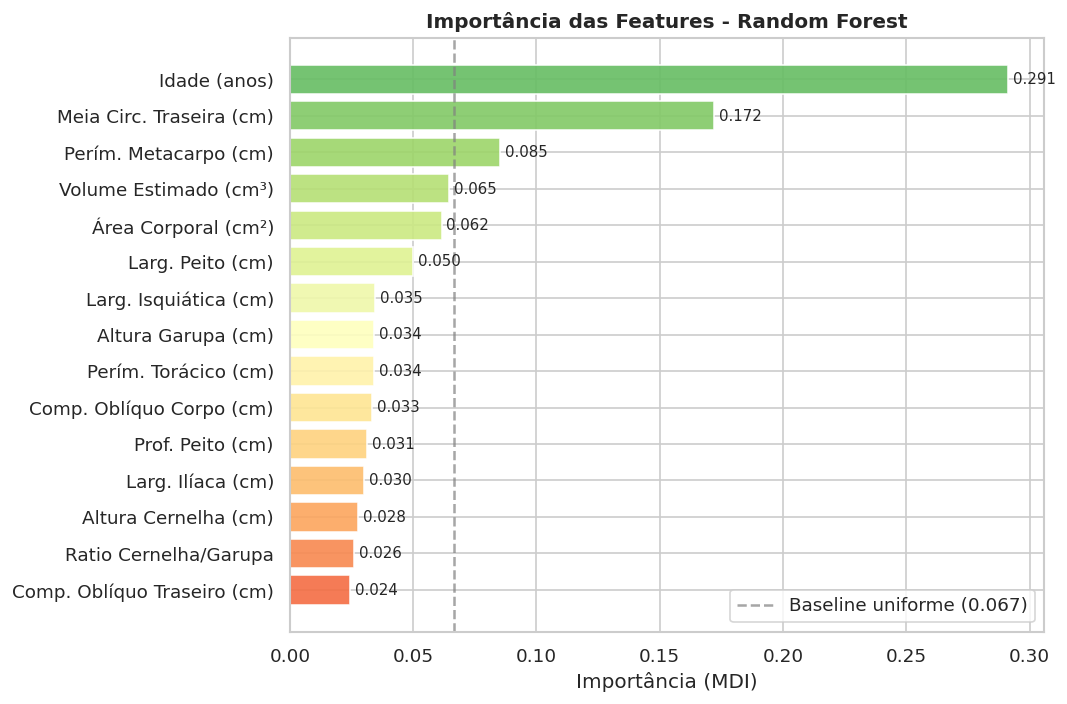

Top 3:
  Idade (anos): 0.291
  Meia Circ. Traseira (cm): 0.172
  Perím. Metacarpo (cm): 0.085


In [35]:
# Importância das features
importancias = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
cores_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(importancias)))
bars = ax.barh([NOMES_PT.get(f, f) for f in importancias.index],
               importancias.values, color=cores_imp, edgecolor='white', alpha=0.9)
for bar, v in zip(bars, importancias.values):
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2, f'{v:.3f}', va='center', fontsize=9)
ax.axvline(1/len(FEATURES), color='gray', linestyle='--', alpha=0.7,
           label=f'Baseline uniforme ({1/len(FEATURES):.3f})')
ax.set_title('Importância das Features - Random Forest', fontweight='bold')
ax.set_xlabel('Importância (MDI)')
ax.legend()
plt.tight_layout()
plt.show()

print('Top 3:')
for f, v in importancias.sort_values(ascending=False).head(3).items():
    print(f'  {NOMES_PT.get(f, f)}: {v:.3f}')

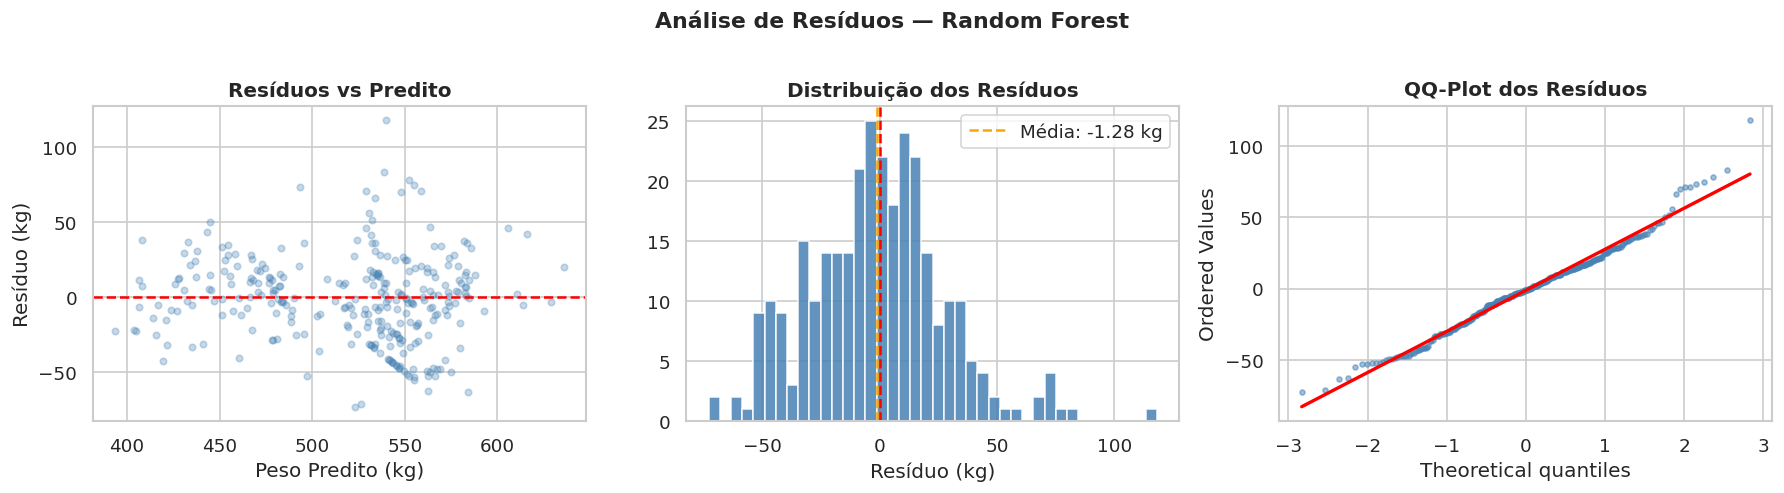

In [36]:
# Análise de resíduos
residuos = y_test.values - pred_rf
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(pred_rf, residuos, alpha=0.3, s=15, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Peso Predito (kg)'); axes[0].set_ylabel('Resíduo (kg)')
axes[0].set_title('Resíduos vs Predito', fontweight='bold')

axes[1].hist(residuos, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].axvline(residuos.mean(), color='orange', linestyle='--',
                label=f'Média: {residuos.mean():.2f} kg')
axes[1].set_xlabel('Resíduo (kg)'); axes[1].set_title('Distribuição dos Resíduos', fontweight='bold')
axes[1].legend()

stats.probplot(residuos, dist='norm', plot=axes[2])
axes[2].set_title('QQ-Plot dos Resíduos', fontweight='bold')
axes[2].get_lines()[0].set(markersize=3, alpha=0.5, color='steelblue')
axes[2].get_lines()[1].set(color='red', linewidth=2)

plt.suptitle('Análise de Resíduos — Random Forest', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Interpretabilidade com SHAP

In [37]:
print('Calculando SHAP values...')
X_shap = pd.DataFrame(X_test_sc, columns=FEATURES)
idx = np.random.choice(len(X_shap), size=min(300, len(X_shap)), replace=False)
X_sample = X_shap.iloc[idx]
X_sample_pt = X_sample.rename(columns=NOMES_PT)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)
print('Pronto')

Calculando SHAP values...
Pronto


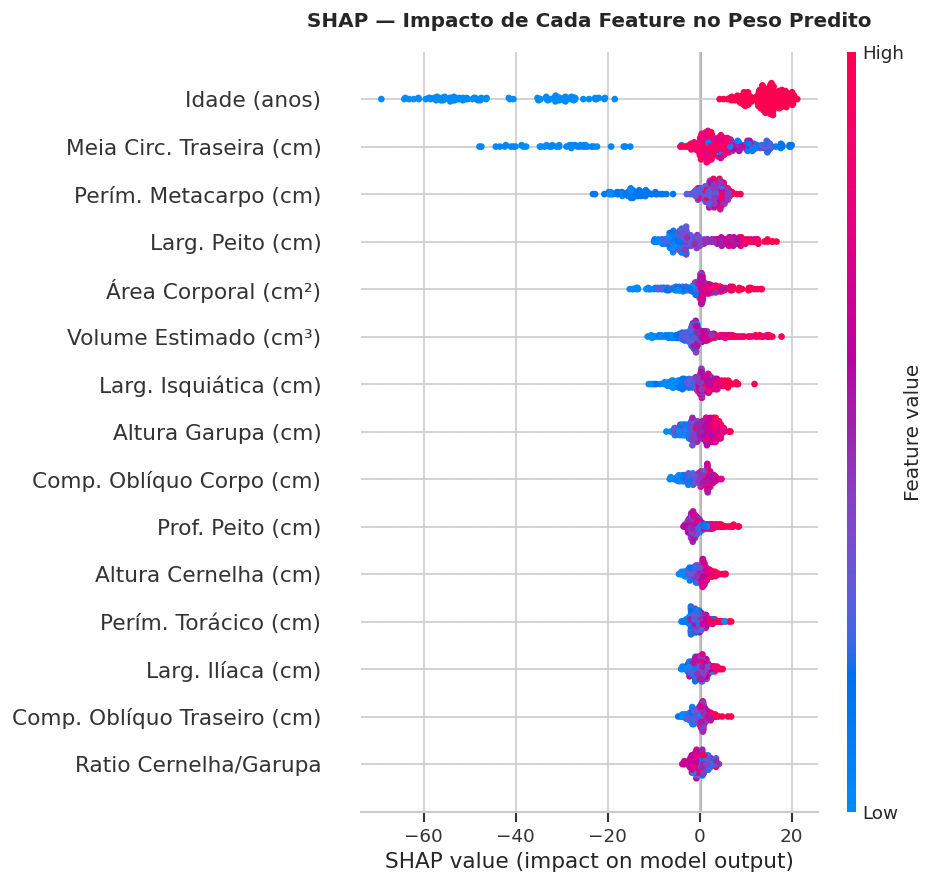

In [38]:
# Beeswarm
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample_pt, plot_type='dot', show=False)
plt.title('SHAP — Impacto de Cada Feature no Peso Predito', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

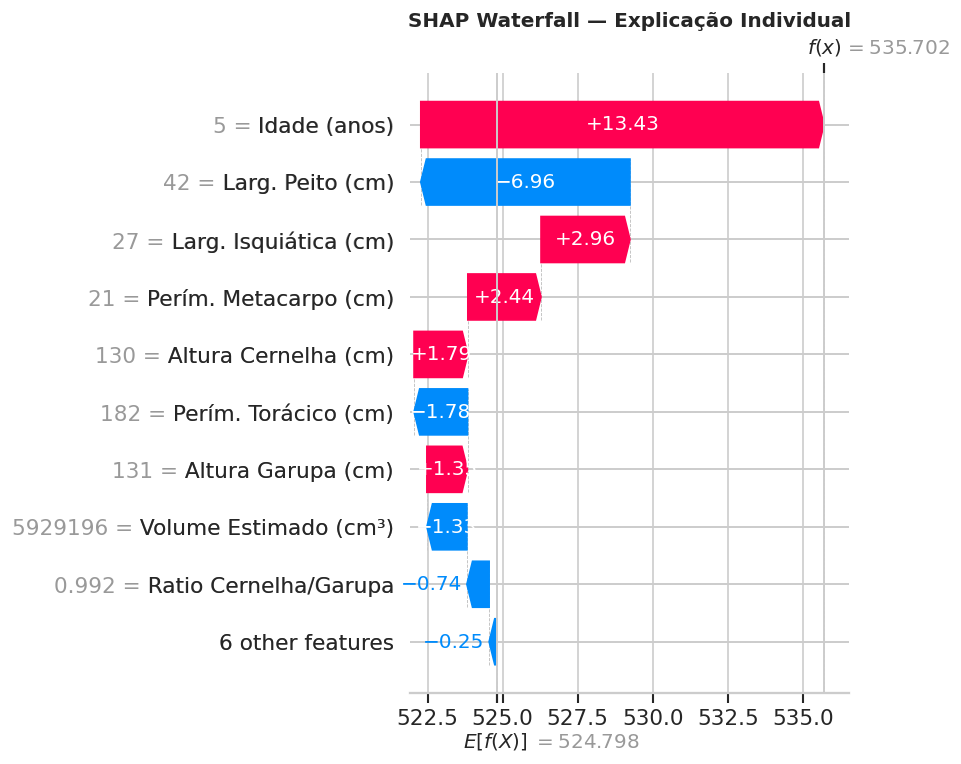

Peso real:    520.0 kg
Peso predito: 535.7 kg


In [39]:
# Waterfall — animal individual com valores reais
pred_sample = rf.predict(X_sample)
idx_mediano = np.argmin(np.abs(pred_sample - np.median(pred_sample)))

# Valores originais (não escalonados) para exibição legível
dados_reais = X_test.reset_index(drop=True).iloc[idx[idx_mediano]].values

explanation = shap.Explanation(
    values=shap_values[idx_mediano],
    base_values=explainer.expected_value,
    data=dados_reais,
    feature_names=[NOMES_PT.get(f, f) for f in FEATURES]
)
plt.figure(figsize=(10, 5))
shap.plots.waterfall(explanation, show=False)
plt.title('SHAP Waterfall — Explicação Individual', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Peso real:    {y_test.values[idx[idx_mediano]]:.1f} kg')
print(f'Peso predito: {pred_sample[idx_mediano]:.1f} kg')

## 8. Simulador de Predição

In [40]:
def estimar_peso(medidas: dict) -> float:
    entrada = pd.DataFrame([medidas])
    entrada['area_corporal']   = entrada['comp_obliquo_corpo'] * entrada['perimetro_toracico']
    entrada['ratio_altura']    = entrada['altura_cernelha'] / entrada['altura_garupa']
    entrada['volume_estimado'] = entrada['perimetro_toracico']**2 * entrada['comp_obliquo_corpo']
    return float(rf.predict(scaler.transform(entrada[FEATURES]))[0])

vaca_exemplo = {
    'altura_cernelha': 132, 'altura_garupa': 135, 'profundidade_peito': 68,
    'largura_peito': 47, 'perimetro_toracico': 198, 'largura_iliaca': 52,
    'largura_isquiatica': 29, 'comp_obliquo_corpo': 156, 'comp_obliquo_traseiro': 39,
    'perimetro_metacarpo': 20, 'meia_circ_traseira': 70, 'idade_anos': 4,
}

peso = estimar_peso(vaca_exemplo)
print('SIMULADOR DE PESO - VACA HEREFORD')
print('-' * 40)
for k, v in vaca_exemplo.items():
    unidade = 'anos' if k == 'idade_anos' else 'cm'
    print(f'  {NOMES_PT.get(k, k):<30} {v:>5} {unidade}')
print()
print(f'  PESO ESTIMADO: {peso:.1f} kg')
print(f'  Intervalo (±MAE): [{peso - mae_rf:.1f}, {peso + mae_rf:.1f}] kg')

SIMULADOR DE PESO - VACA HEREFORD
----------------------------------------
  Altura Cernelha (cm)             132 cm
  Altura Garupa (cm)               135 cm
  Prof. Peito (cm)                  68 cm
  Larg. Peito (cm)                  47 cm
  Perím. Torácico (cm)             198 cm
  Larg. Ilíaca (cm)                 52 cm
  Larg. Isquiática (cm)             29 cm
  Comp. Oblíquo Corpo (cm)         156 cm
  Comp. Oblíquo Traseiro (cm)       39 cm
  Perím. Metacarpo (cm)             20 cm
  Meia Circ. Traseira (cm)          70 cm
  Idade (anos)                       4 anos

  PESO ESTIMADO: 539.1 kg
  Intervalo (±MAE): [517.0, 561.3] kg


## 9. Conclusões

| Modelo | MAE (kg) | R² |
|---|---|---|
| Regressão Linear | 29.26 | 0.572 |
| Ridge | 29.23 | 0.573 |
| KNN (k=7) | 25.74 | 0.649 |
| SVR (RBF) | 24.63 | 0.675 |
| Gradient Boosting | 23.73 | 0.702 |
| XGBoost tunado | 22.41 | 0.733 |
| **Random Forest tunado** | **22.15** | **0.734** |

**Referência (Ruchay et al., 2022):** Random Forest R²=0.713, MAE=24.97 kg  
**Resultado obtido:** R²=0.734, MAE=22.15 kg, superando o baseline do artigo original.

O Random Forest com RandomizedSearchCV se manteve superior em todos os cenários testados, incluindo XGBoost com otimização de hiperparâmetros. O erro relativo médio de 4.3% num animal de ~519 kg indica viabilidade prática como alternativa à balança industrial.

**Limitações:**
- Dataset coletado na Rússia, validação com animais do Pampa gaúcho é necessária.
- Medidas manuais introduzem erro do operador (~2–3 cm).
- Modelo não inclui condição corporal (ECC) nem estado reprodutivo.
- Teto do dataset estimado em R²≈0.75, limitação biológica do problema.

**Referência:**  
Ruchay et al. (2022). Comparative analysis of machine learning algorithms for predicting live weight of Hereford cows. *Computers and Electronics in Agriculture*, 195, 106893. https://doi.org/10.1016/j.compag.2022.106893

In [41]:
# Salvar modelo
os.makedirs('models', exist_ok=True)
with open('models/rf_peso_hereford.pkl', 'wb') as f:
    pickle.dump({'modelo': rf, 'scaler': scaler, 'features': FEATURES,
                 'metricas': {'mae': mae_rf, 'rmse': rmse_rf, 'r2': r2_rf}}, f)
print('Modelo salvo em models/rf_peso_hereford.pkl')

Modelo salvo em models/rf_peso_hereford.pkl
